Nos basamos en el Pipeline ML de la clase: Ingesta & Exploración → Entrenamiento → Predicción → Evaluación, y en la arquitectura correcta Shuffle & Split para evitar evaluar con datos ya vistos.

# Justificación

Este primer paso cumple la base metodológica: definir problema, variable objetivo, variables predictoras y partición honesta de datos. Como el objetivo machine_failure es binario, el proyecto se plantea como clasificación supervisada.

In [ ]:
from __future__ import division, print_function, unicode_literals

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

# Carga del dataset del proyecto
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

# Limpieza de nombres, igual que en el EDA del proyecto
df.columns = df.columns.str.strip()

df.rename(columns={
    'Air temperature [K]': 'air_temp',
    'Process temperature [K]': 'process_temp',
    'Rotational speed [rpm]': 'rot_speed',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'tool_wear',
    'Machine failure': 'machine_failure'
}, inplace=True)

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,air_temp,process_temp,rot_speed,torque,tool_wear,machine_failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


machine_failure
0    9661
1     339
Name: count, dtype: int64
machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64


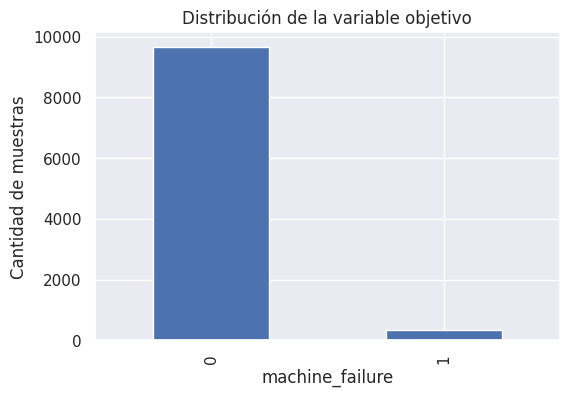

In [ ]:
# ============================================================
# 2. DEFINICIÓN DEL PROBLEMA SUPERVISADO
# ============================================================

print(df['machine_failure'].value_counts())
print(df['machine_failure'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
df['machine_failure'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('machine_failure')
plt.ylabel('Cantidad de muestras')
plt.title('Distribución de la variable objetivo')
plt.show()

In [ ]:
# ============================================================
# 3. CODIFICACIÓN DE VARIABLE CATEGÓRICA DEL EDA
# ============================================================

le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])

for clase, codigo in zip(le.classes_, range(len(le.classes_))):
    print(clase, "->", codigo)

H -> 0
L -> 1
M -> 2


In [ ]:
# ============================================================
# 4. MATRIZ X Y VECTOR y
# ============================================================

feature_cols = [
    'Type_encoded',
    'air_temp',
    'process_temp',
    'rot_speed',
    'torque',
    'tool_wear'
]

X = df[feature_cols].values
y = df['machine_failure'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 6)
y shape: (10000,)


In [ ]:
# ============================================================
# 5. SHUFFLE & SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=21
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

print("\nDistribución en entrenamiento:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

print("\nDistribución en prueba:")
print(pd.Series(y_test).value_counts(normalize=True) * 100)

X_train: (8000, 6)
X_test:  (2000, 6)
y_train: (8000,)
y_test:  (2000,)

Distribución en entrenamiento:
0    96.725
1     3.275
Name: proportion, dtype: float64

Distribución en prueba:
0    96.15
1     3.85
Name: proportion, dtype: float64


# Conclusión del Modelo

Todavía no entrenamos modelos. En este paso dejamos listo el Pipeline ML base: el problema es de clasificación binaria, donde 0 significa máquina sin falla y 1 significa máquina con falla. La partición train_test_split(test_size=0.2, random_state=21) garantiza que todos los modelos de clase se comparen bajo las mismas condiciones.

# Referencia de Clase

Nos basamos en la Exploración Visual: Entendiendo la Separabilidad (diapositiva de EDA) donde se analizan:

Distribuciones (histogramas)
Separabilidad entre clases
Correlaciones entre variables

# Justificación

Este paso cumple:

Análisis exploratorio profundo del dataset
Interpretación visual de variables
Justificación del comportamiento esperado de los modelos

La rúbrica exige entender si las variables permiten separar la clase machine_failure.

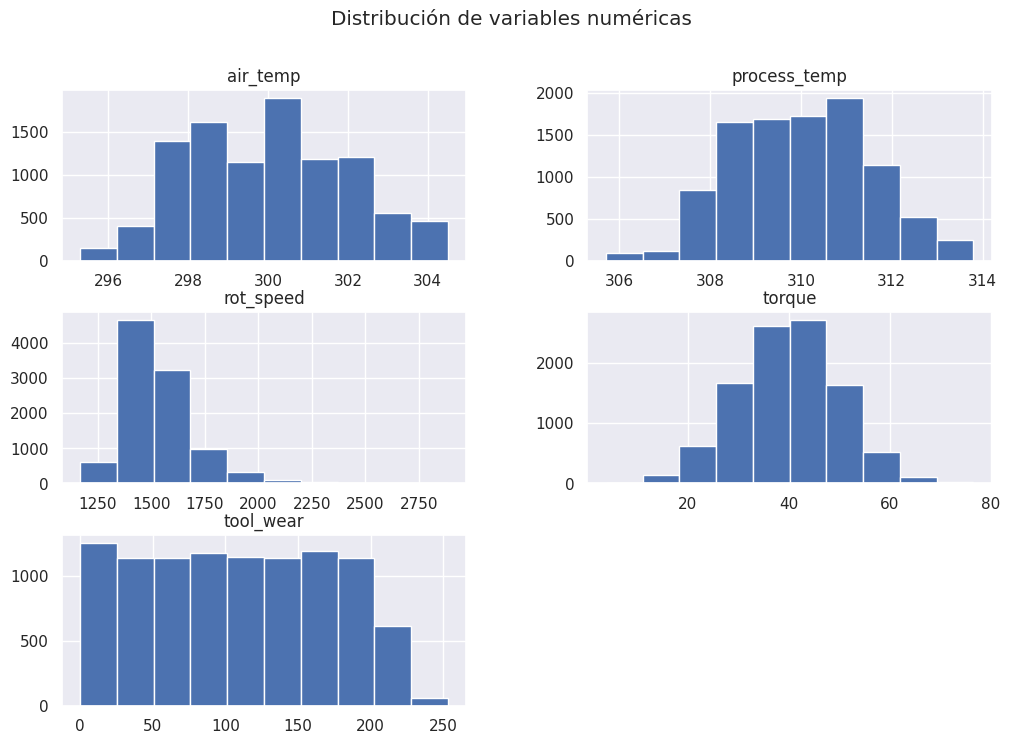

In [ ]:
# ============================================================
# DISTRIBUCIONES DE LAS VARIABLES (CHECKLIST: DISTRIBUTIONS)
# ============================================================

df[[
    'air_temp',
    'process_temp',
    'rot_speed',
    'torque',
    'tool_wear'
]].hist(figsize=(12,8))

plt.suptitle("Distribución de variables numéricas")
plt.show()

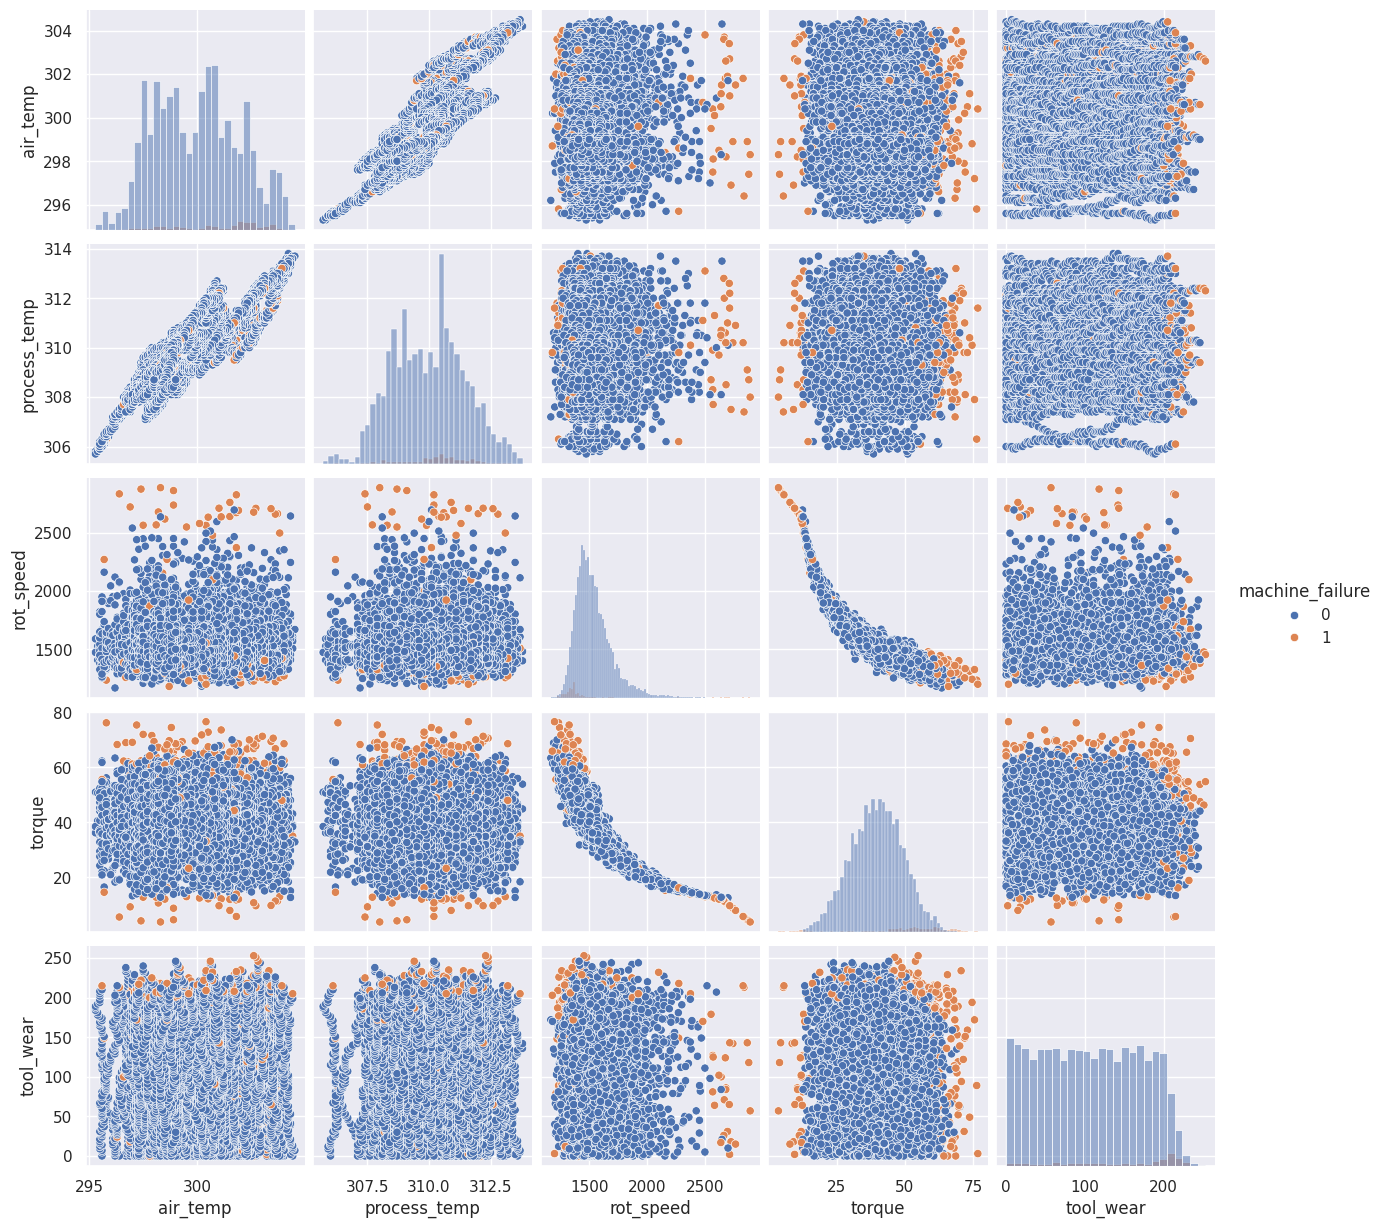

In [ ]:
# ============================================================
# SEPARABILIDAD ENTRE CLASES (CHECKLIST: SEPARABILITY)
# ============================================================

sns.pairplot(
    df[[
        'air_temp',
        'process_temp',
        'rot_speed',
        'torque',
        'tool_wear',
        'machine_failure'
    ]],
    hue='machine_failure',
    diag_kind='hist'
)

plt.show()

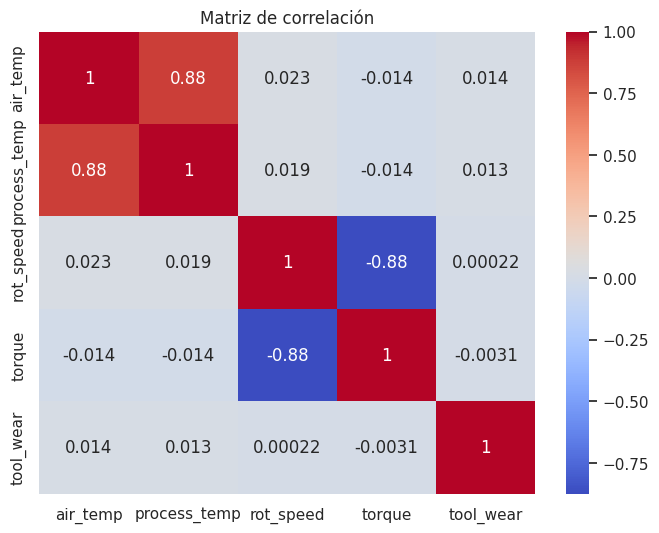

In [ ]:
# ============================================================
# MATRIZ DE CORRELACIÓN (CHECKLIST: CORRELATION)
# ============================================================

plt.figure(figsize=(8,6))
sns.heatmap(
    df[[
        'air_temp',
        'process_temp',
        'rot_speed',
        'torque',
        'tool_wear'
    ]].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Matriz de correlación")
plt.show()

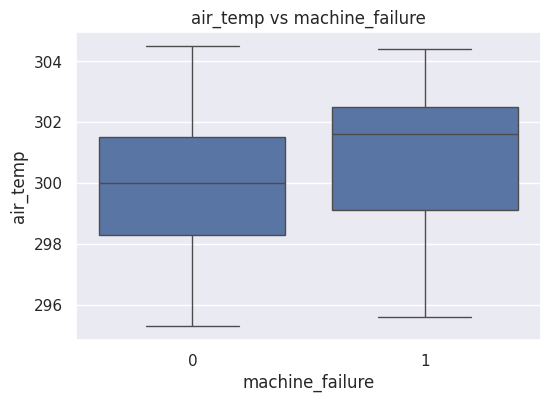

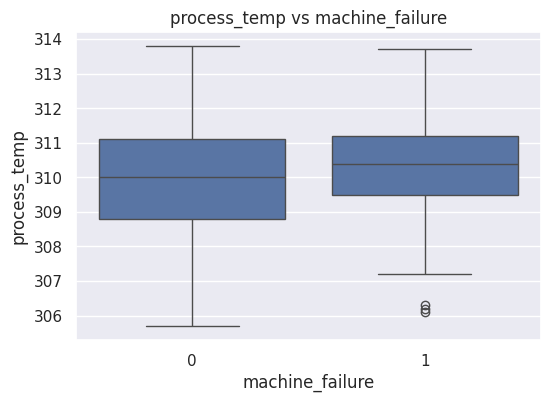

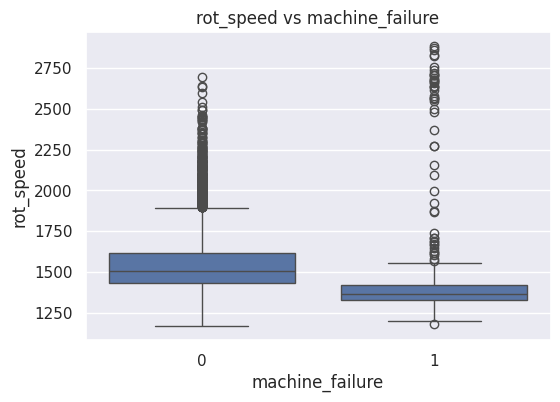

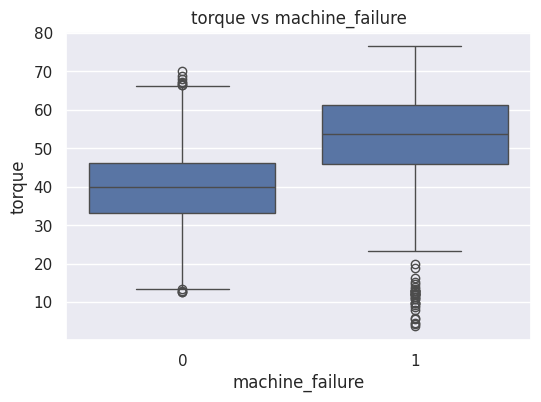

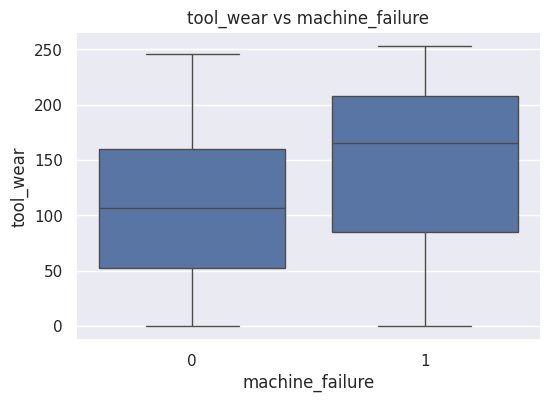

In [ ]:
# ============================================================
# RELACIÓN INDIVIDUAL CON LA VARIABLE OBJETIVO
# ============================================================

variables = ['air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear']

for var in variables:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='machine_failure', y=var, data=df)
    plt.title(f"{var} vs machine_failure")
    plt.show()

# Conclusión del Modelo (EDA)


*   Distribuciones: permiten verificar si hay variables sesgadas o con outliers
(importante para modelos como Naive Bayes y SVM).
*   Separabilidad: si las clases 0 y 1 se separan visualmente, modelos simples pueden funcionar bien.


*   Correlación: alta correlación puede afectar modelos que asumen independencia (Naive Bayes).
*   Boxplots: ayudan a ver qué variables cambian significativamente cuando hay falla.


## Interpretación para mantenimiento predictivo:

Si variables como torque o tool_wear muestran diferencias claras entre clases, serán claves para detectar fallas.
Si la separabilidad es baja, necesitaremos modelos más complejos (SVM, Random Forest).
Este análisis guía qué modelo tendrá mejor desempeño en detectar fallas (especialmente reducir falsos negativos).

# Referencia de Clase

Nos basamos en el flujo de preprocesamiento previo al entrenamiento, donde:



*   Se trabaja sobre X_train y X_test ya definidos
*   Se aplica escalado (StandardScaler) cuando el modelo lo requiere (ej. SVM)
*   Nunca se ajusta el scaler con datos de test (evitar data leakage)Esto sigue la arquitectura correcta del pipeline vista en clase


## Justificación
Este paso cumple:


*   Preparación adecuada de datos
*   Aplicación correcta de técnicas de preprocesamiento
*   Evitar fuga de información (data leakage)
*   Elemento de lista

Además, garantiza que la comparación entre modelos sea justa y reproducible.

In [ ]:
# ============================================================
# PREPROCESAMIENTO - ESCALADO (STANDARD SCALER)
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ajuste SOLO con entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformación en test
X_test_scaled = scaler.transform(X_test)

print("Media (train):", X_train_scaled.mean(axis=0))
print("Std (train):", X_train_scaled.std(axis=0))

Media (train): [ 1.07136522e-17  4.25744190e-13 -9.58760238e-13  4.07951450e-16
 -1.30400690e-14 -8.26422264e-17]
Std (train): [1. 1. 1. 1. 1. 1.]


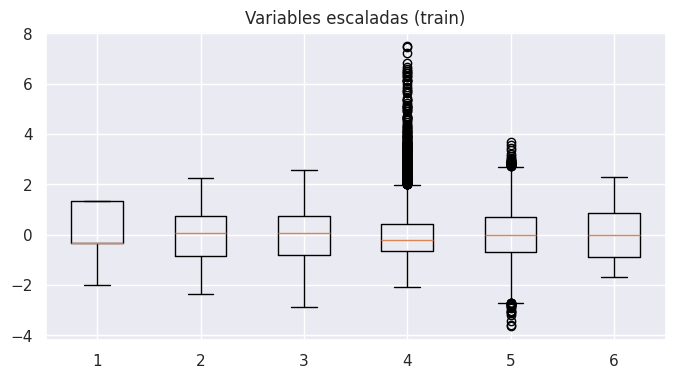

In [ ]:
# ============================================================
# VISUALIZACIÓN POST-ESCALADO
# ============================================================

plt.figure(figsize=(8,4))
plt.boxplot(X_train_scaled)
plt.title("Variables escaladas (train)")
plt.show()

In [ ]:
# ============================================================
# MATRICES FINALES PARA MODELOS
# ============================================================

# Modelos que usarán datos escalados:
X_train_svm = X_train_scaled
X_test_svm = X_test_scaled

# Modelos que NO requieren escalado (árboles, Naive Bayes):
X_train_base = X_train
X_test_base = X_test

# Conclusión del Modelo



*   El escalado transforma las variables a media 0 y desviación estándar 1, evitando que variables con mayor magnitud dominen el modelo.
*   Es crítico para SVM, ya que este modelo depende de distancias en el espacio de características.


*   No es necesario para:
  *   Árboles de decisión
  *   Random Forest
  *   Naive Bayes (según implementación de clase)
# Interpretación en mantenimiento predictivo:



*   Variables como rot_speed y torque tienen escalas distintas; sin normalización,
SVM podría dar más peso a una variable incorrectamente.
*   Este paso asegura que el modelo aprenda patrones reales de falla, no sesgos por escala.






# Referencia de Clase

Nos basamos en el modelo Gaussian Naive Bayes visto en clase, donde:

Se asume independencia entre variables
Se modela cada feature con distribución normal


Y seguimos el flujo estándar:

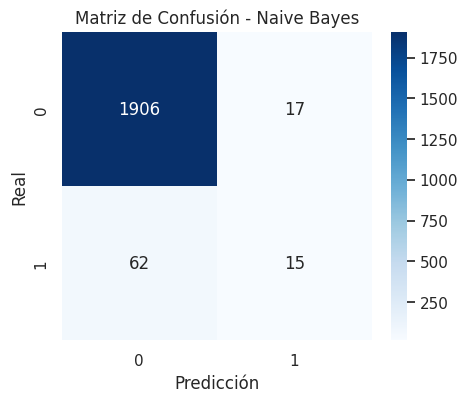

In [ ]:
# ============================================================
# MODELO 1: GAUSSIAN NAIVE BAYES
# ============================================================

from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

# Entrenamiento (usa datos SIN escalar según clase)
gnb.fit(X_train_base, y_train)

y_pred_gnb = gnb.predict(X_test_base)

# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================

cm = confusion_matrix(y_test, y_pred_gnb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Naive Bayes')
plt.show()

In [ ]:
# ============================================================
# MÉTRICAS DE CLASIFICACIÓN
# ============================================================

acc = accuracy_score(y_test, y_pred_gnb)
recall = recall_score(y_test, y_pred_gnb)
precision = precision_score(y_test, y_pred_gnb)
f1 = f1_score(y_test, y_pred_gnb)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_gnb).ravel()
specificity = tn / (tn + fp)

print("Accuracy:", acc)
print("Recall (Sensibilidad):", recall)
print("Precision:", precision)
print("Specificity:", specificity)
print("F1-score:", f1)

Accuracy: 0.9605
Recall (Sensibilidad): 0.19480519480519481
Precision: 0.46875
Specificity: 0.9911596463858554
F1-score: 0.27522935779816515


# Conclusión del Modelo
Naive Bayes asume independencia entre variables, lo cual en este dataset no es completamente cierto (ej: temperatura y proceso).
Es un modelo rápido pero simple, por lo que:
Puede tener buen desempeño general (accuracy)
Pero puede fallar en detectar correctamente fallas (recall bajo)

## Interpretación en mantenimiento predictivo:

Lo más crítico es el recall (sensibilidad) → detectar fallas reales
Si el modelo tiene muchos falsos negativos, es peligroso:
 máquina falla pero el modelo dice que no

Este modelo nos sirve como referencia:

Todo modelo posterior debe superar este desempeño

## Referencia de Clase

Nos basamos en Support Vector Machine (SVM) visto en clase, usando el flujo estándar:
SVM necesita datos escalados porque trabaja con separación geométrica entre clases.

Justificación

Este paso cumple:



*   Entrenamiento de un segundo modelo de clasificación.
*   Comparación bajo la misma partición train/test.
*   Uso de métricas obligatorias: accuracy, recall, precision, especificidad y F1.





In [ ]:
# ============================================================
# MODELO 2: SUPPORT VECTOR MACHINE
# ============================================================

from sklearn.svm import SVC

svm_model = SVC(kernel='rbf',class_weight="balanced",C=10,gamma="scale")

# SVM usa datos escalados
svm_model.fit(X_train_scaled, y_train)


y_pred_svm = svm_model.predict(X_test_scaled)

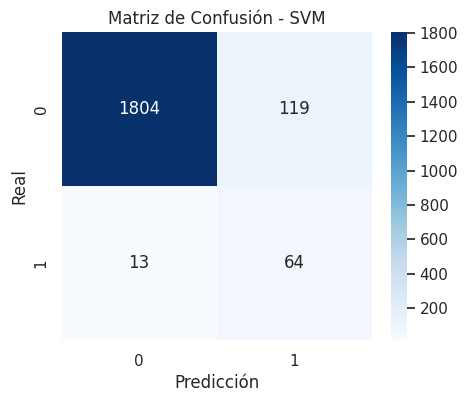

In [ ]:
# ============================================================
# MATRIZ DE CONFUSIÓN - SVM
# ============================================================

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - SVM')
plt.show()

In [ ]:
# ============================================================
# MÉTRICAS - SVM
# ============================================================

acc_svm = accuracy_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_svm).ravel()
specificity_svm = tn / (tn + fp)

print("Accuracy:", acc_svm)
print("Recall (Sensibilidad):", recall_svm)
print("Precision:", precision_svm)
print("Specificity:", specificity_svm)
print("F1-score:", f1_svm)

Accuracy: 0.934
Recall (Sensibilidad): 0.8311688311688312
Precision: 0.34972677595628415
Specificity: 0.9381175247009881
F1-score: 0.49230769230769234


Aunque SVM obtuvo 93% de accuracy, el recall fue 0.83. Esto demuestra que accuracy no es suficiente en datasets desbalanceados. El modelo no falló completamente en detectar fallas reales, por lo tanto podríamos tener en cuenta para comparar a la finalidad con los demás

# Referencia de Clase

Nos basamos en Decision Tree Classifier, donde el árbol:



*   Parte desde una raíz
*   Divide usando preguntas binarias
*   Escoge divisiones con impureza de Gini
*   Elemento de lista
*   Termina en hojas con predicción de clase

## Justificación

Este modelo cumple con:



*   Uso de un algoritmo visto en clase
*   Interpretabilidad del modelo
*   Evaluación con métricas más adecuadas que solo accuracy
*   Análisis de falsos negativos para mantenimiento predictivo





In [ ]:
# ============================================================
# MODELO 3: DECISION TREE CLASSIFIER
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=21
)

# Árboles usan datos SIN escalar
tree_model.fit(X_train_base, y_train)

y_pred_tree = tree_model.predict(X_test_base)

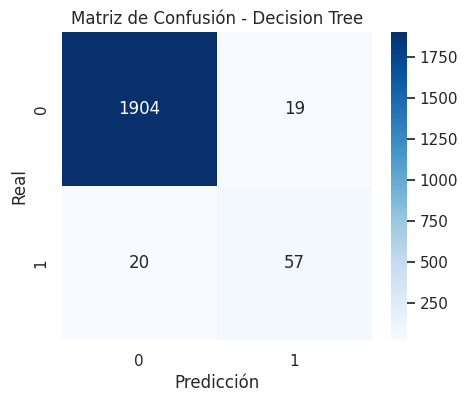

In [ ]:
# ============================================================
# MATRIZ DE CONFUSIÓN - DECISION TREE
# ============================================================

cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Decision Tree')
plt.show()

In [ ]:
# ============================================================
# MÉTRICAS - DECISION TREE
# ============================================================

acc_tree = accuracy_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tree).ravel()
specificity_tree = tn / (tn + fp)

print("Accuracy:", acc_tree)
print("Recall (Sensibilidad):", recall_tree)
print("Precision:", precision_tree)
print("Specificity:", specificity_tree)
print("F1-score:", f1_tree)

Accuracy: 0.9805
Recall (Sensibilidad): 0.7402597402597403
Precision: 0.75
Specificity: 0.9901196047841914
F1-score: 0.7450980392156863


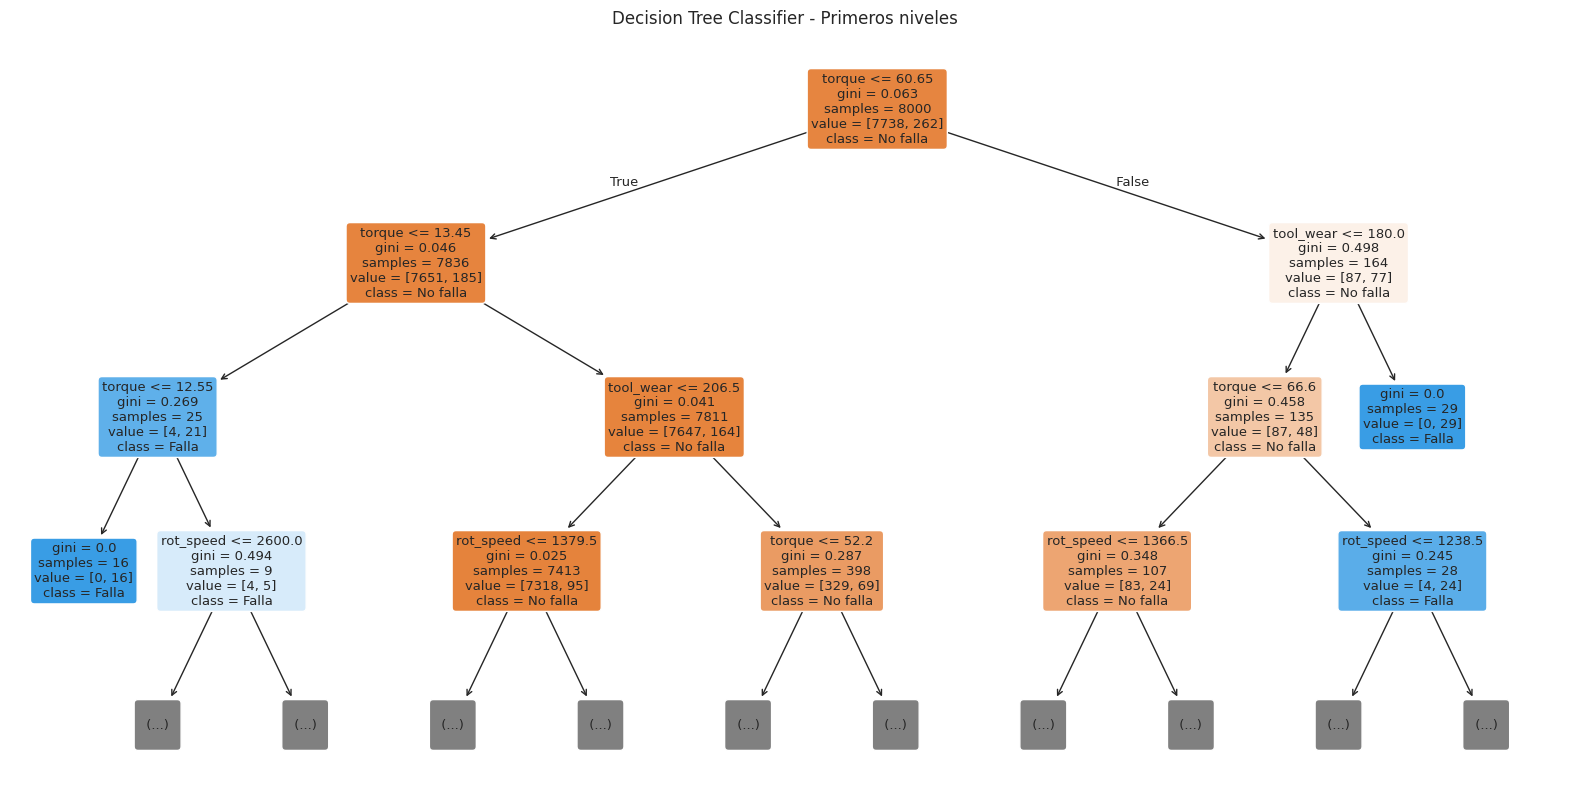

In [ ]:
# ============================================================
# VISUALIZACIÓN DEL ÁRBOL
# ============================================================

plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    feature_names=feature_cols,
    class_names=['No falla', 'Falla'],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Classifier - Primeros niveles")
plt.show()

Decision Tree mostró un desempeño significativamente superior al SVM. Aunque ambos modelos tuvieron accuracy alta, el árbol logró detectar el 74% de las fallas reales, mientras que SVM no detectó ninguna. Esto demuestra que en datasets desbalanceados no basta con evaluar accuracy.

# Nos basamos en Random Forest Classifier, donde:



*   Se construyen múltiples Decision Trees
*   Cada árbol usa muestras aleatorias (bootstrap)
*   La predicción final se hace por votación

# Justificación

Este paso cumple:



*   Implementación de ensamble de modelos
*   Comparación de rendimiento entre algoritmos
*   Evaluación robusta usando múltiples métricas

**Además,  es el modelo más fuerte del proyecto.**

In [ ]:
# ============================================================
# MODELO 4: RANDOM FOREST CLASSIFIER
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    random_state=21
)

rf_model.fit(X_train_base, y_train)
y_pred_rf = rf_model.predict(X_test_base)

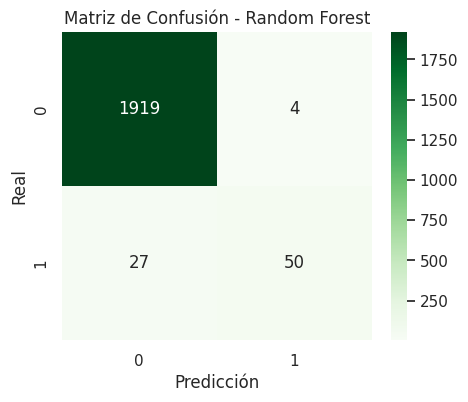

In [ ]:
# ============================================================
# MATRIZ DE CONFUSIÓN - RANDOM FOREST
# ============================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest')

plt.show()

In [ ]:
# ============================================================
# MÉTRICAS - RANDOM FOREST
# ============================================================

acc_rf = accuracy_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
specificity_rf = tn / (tn + fp)

print("Accuracy:", acc_rf)
print("Recall (Sensibilidad):", recall_rf)
print("Precision:", precision_rf)
print("Specificity:", specificity_rf)
print("F1-score:", f1_rf)

Accuracy: 0.9845
Recall (Sensibilidad): 0.6493506493506493
Precision: 0.9259259259259259
Specificity: 0.9979199167966719
F1-score: 0.7633587786259542


In [ ]:
# ============================================================
# IMPORTANCIA DE VARIABLES
# ============================================================

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Variable': feature_cols,
    'Importancia': importances
})

importance_df = importance_df.sort_values(
    by='Importancia',
    ascending=False
)

print(importance_df)

       Variable  Importancia
4        torque     0.323933
3     rot_speed     0.233572
5     tool_wear     0.162127
1      air_temp     0.137251
2  process_temp     0.118343
0  Type_encoded     0.024774


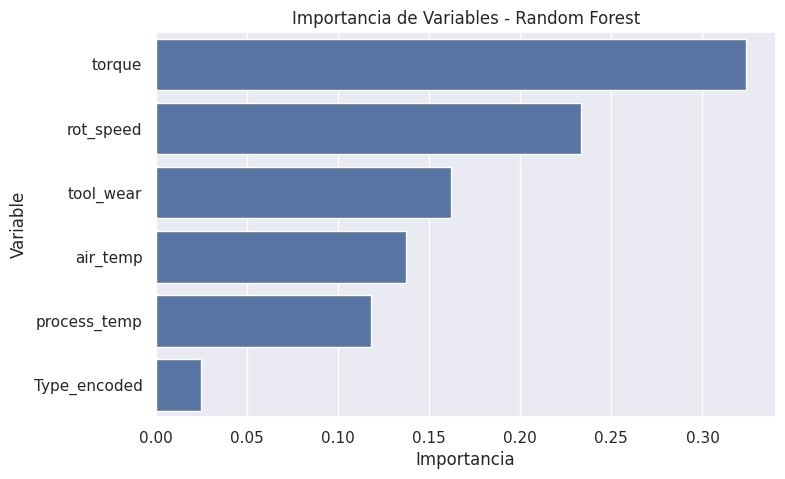

In [ ]:
# ============================================================
# GRÁFICA DE IMPORTANCIA
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x='Importancia',
    y='Variable'
)

plt.title('Importancia de Variables - Random Forest')

plt.show()

# Conclusión del Modelo

Random Forest mejora el desempeño porque:



*   combina múltiples árboles
*   reduce sobreajuste
*   aprende relaciones complejas entre variables

En mantenimiento predictivo:



*   un recall alto significa detectar más fallas reales
*   un F1-score alto indica equilibrio entre:


1.   detectar fallas
2.   evitar falsas alarmas


La gráfica de importancia permite identificar:

Qué variables influyen más en las fallas de maquinaria.

In [ ]:
# ============================================================
# TABLA COMPARATIVA FINAL
# ============================================================

results_df = pd.DataFrame({

    'Modelo': [
        'Gaussian Naive Bayes',
        'SVM',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        acc,
        acc_svm,
        acc_tree,
        acc_rf
    ],

    'Recall': [
        recall,
        recall_svm,
        recall_tree,
        recall_rf
    ],

    'Precision': [
        precision,
        precision_svm,
        precision_tree,
        precision_rf
    ],

    'Specificity': [
        specificity,
        specificity_svm,
        specificity_tree,
        specificity_rf
    ],

    'F1-score': [
        f1,
        f1_svm,
        f1_tree,
        f1_rf
    ]
})

results_df

,Modelo,Accuracy,Recall,Precision,Specificity,F1-score
0,Gaussian Naive Bayes,0.9605,0.194805,0.468750,0.991160,0.275229
1,SVM,0.9340,0.831169,0.349727,0.938118,0.492308
2,Decision Tree,0.9805,0.740260,0.750000,0.990120,0.745098
3,Random Forest,0.9845,0.649351,0.925926,0.997920,0.763359


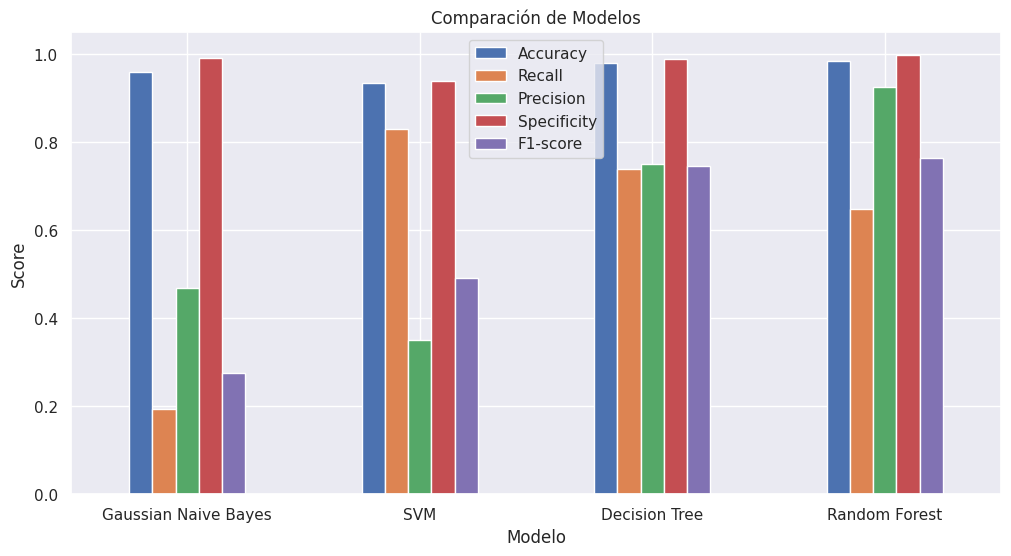

In [ ]:
# ============================================================
# COMPARACIÓN VISUAL DE MODELOS
# ============================================================

metrics_plot = results_df.set_index('Modelo')

metrics_plot.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Comparación de Modelos')
plt.ylabel('Score')
plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.show()